In [ ]:
# ==========================================
# CELL 1 : LOAD ZIP DATASET FROM GIVEN PATH
# ==========================================

import os
import zipfile

zip_path = r"C:\Users\digvi\Downloads\Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network.zip"

extract_folder = r"C:\Users\digvi\Downloads\PlantDataset"

# Create folder if not exists
os.makedirs(extract_folder, exist_ok=True)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset Extracted Successfully!")
print("Extracted To:", extract_folder)

Dataset Extracted Successfully!
Extracted To: C:\Users\digvi\Downloads\PlantDataset


In [5]:
# ==========================================
# CELL 2 : EXTRACT YOUR ZIP DATASET
# ==========================================
zip_path = r"C:\Users\digvi\Downloads\Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network.zip"

extract_folder = r"C:\Users\digvi\Downloads\PlantDataset"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
# ==========================================
# CELL 3 : CHECK EXTRACTED FOLDERS
# ==========================================
print(os.listdir(extract_folder))

['Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network', 'FinalDataset']


In [8]:
# ==========================================
# CELL 4 : GIVE DATASET FOLDER PATH
# IMPORTANT:
# Run previous cell and see class folders
# Example:
# PlantDataset/
#    Healthy/
#    Early_Blight/
#    Late_Blight/
# ==========================================

DATASET_DIR = extract_folder

In [9]:
# ==========================================
# CELL 5 : SETTINGS
# ==========================================
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42

In [10]:
# ==========================================
# FIX FOR CELL 6 ERROR
# Run this cell before CELL 6
# ==========================================

from tensorflow.keras.preprocessing import image_dataset_from_directory

In [11]:
# ==========================================
# FIX FOR CELL 6
# No images found means DATASET_DIR is wrong
# Run this cell first
# ==========================================

import os

print("Main Folder:")
print(os.listdir(extract_folder))

Main Folder:
['Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network', 'FinalDataset']


In [12]:
# ==========================================
# RUN THIS NOW
# We need actual inner folder names
# ==========================================

import os

for root, dirs, files in os.walk(extract_folder):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)

FOLDER: C:\Users\digvi\Downloads\PlantDataset
SUBFOLDERS: ['Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network', 'FinalDataset']
FILES: []
--------------------------------------------------
FOLDER: C:\Users\digvi\Downloads\PlantDataset\Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network
SUBFOLDERS: []
FILES: ['Plant_leaf_diseases_dataset_without_augmentation.zip', 'Plant_leaf_diseases_dataset_with_augmentation.zip']
--------------------------------------------------
FOLDER: C:\Users\digvi\Downloads\PlantDataset\FinalDataset
SUBFOLDERS: ['Plant_leave_diseases_dataset_with_augmentation']
FILES: []
--------------------------------------------------
FOLDER: C:\Users\digvi\Downloads\PlantDataset\FinalDataset\Plant_leave_diseases_dataset_with_augmentation
SUBFOLDERS: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']
FILES: []
-------

In [13]:
# ==========================================
# YOUR MAIN ZIP CONTAINS ANOTHER ZIP FILE
# We need to extract inner dataset zip
# Run this now
# ==========================================

import os
import zipfile

inner_zip = r"C:\Users\digvi\Downloads\PlantDataset\Data for Identification of Plant Leaf Diseases Using a 9-layer Deep Convolutional Neural Network\Plant_leaf_diseases_dataset_with_augmentation.zip"

final_extract = r"C:\Users\digvi\Downloads\PlantDataset\FinalDataset"

os.makedirs(final_extract, exist_ok=True)

with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall(final_extract)

print("Inner Dataset Extracted Successfully!")
print(os.listdir(final_extract))

Inner Dataset Extracted Successfully!
['Plant_leave_diseases_dataset_with_augmentation']


In [14]:
# ==========================================
# NOW SET CORRECT DATASET PATH
# Run this before CELL 6
# ==========================================

DATASET_DIR = r"C:\Users\digvi\Downloads\PlantDataset\FinalDataset\Plant_leave_diseases_dataset_with_augmentation"

print("Correct Dataset Path Set")

Correct Dataset Path Set


In [15]:
# ==========================================
# CELL 6 : LOAD DATASET (CORRECTED)
# Run after setting DATASET_DIR
# ==========================================

from tensorflow.keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

print("Dataset Loaded Successfully!")

Found 61486 files belonging to 39 classes.
Using 49189 files for training.
Found 61486 files belonging to 39 classes.
Using 12297 files for validation.
Dataset Loaded Successfully!


In [16]:
# ==========================================
# CELL 7 : SHOW CLASS NAMES
# ==========================================

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes Found:")
print(class_names)
print("Total Classes:", num_classes)

Classes Found:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Y

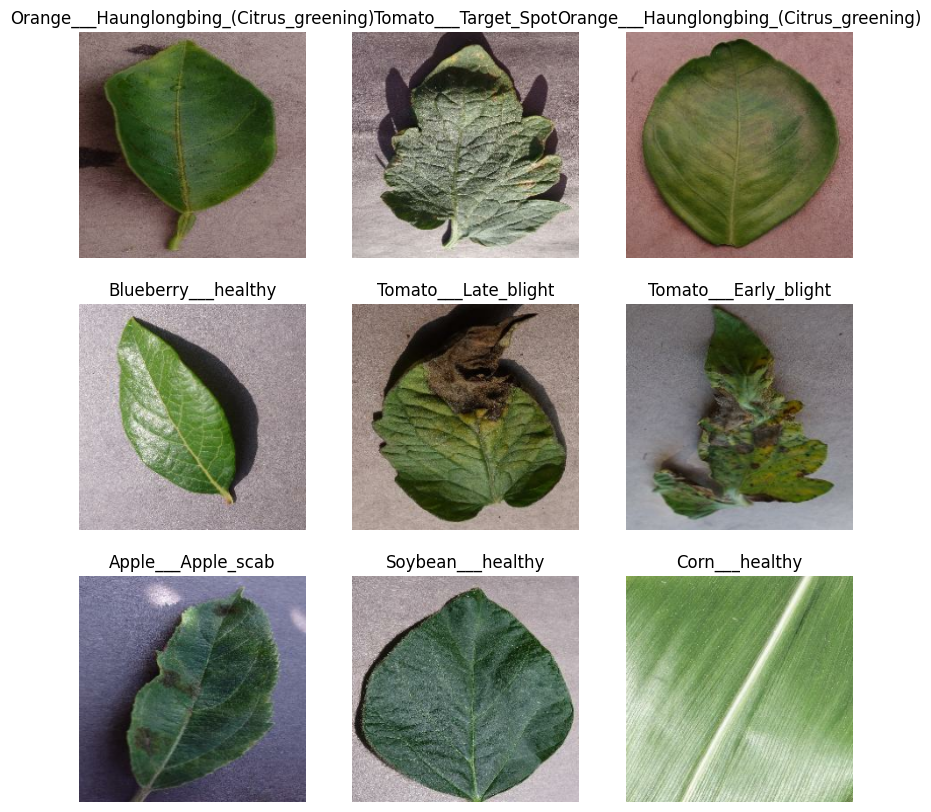

In [17]:
# ==========================================
# CELL 8 : SHOW SAMPLE IMAGES
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [18]:
# ==========================================
# CELL 9 : DATA AUGMENTATION
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [19]:
# ==========================================
# CELL 10 : LOAD BASE MODEL
# ==========================================

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [20]:
# ==========================================
# CELL 11 : BUILD MODEL
# ==========================================

from tensorflow.keras import models

inputs = tf.keras.Input(shape=(224,224,3))

x = data_aug(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [21]:
# ==========================================
# CELL 12 : COMPILE MODEL
# ==========================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        49,959 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,307,943 (8.80 MB)

 Trainable params: 49,959 (195.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================================
# CELL 13 : TRAIN MODEL (FAST VERSION)
# Reduced epochs for quick training
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

  14/1538 ━━━━━━━━━━━━━━━━━━━━ 15:54 627ms/step - accuracy: 0.9098 - loss: 0.2620

KeyboardInterrupt: 

In [35]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


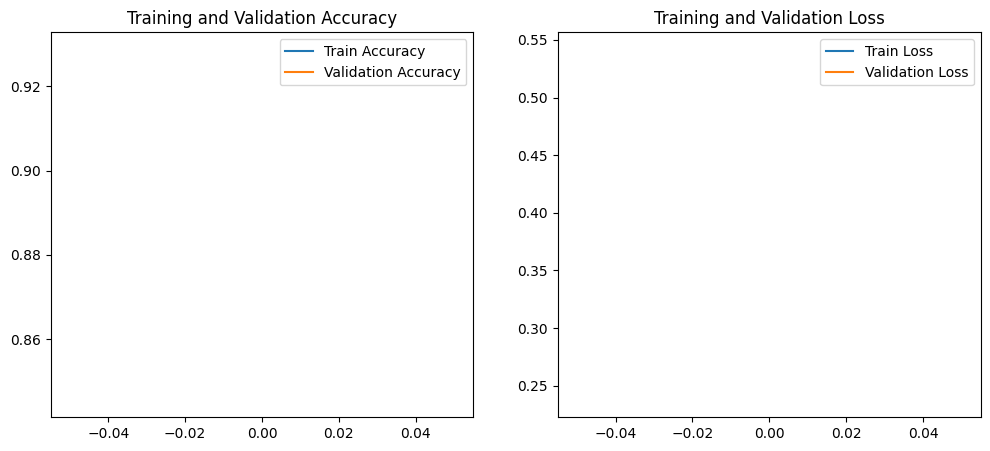

In [ ]:
\


In [25]:
# ==========================================
# CELL 15 : SAVE MODEL
# ==========================================

model.save("leaf_disease_model.h5")
print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
# ==========================================
# CELL 16 : LOAD MODEL FOR TESTING
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import load_model

try:
    # Try loading with compile=False (most reliable for prediction use)
    model = load_model("leaf_disease_model.h5", compile=False)
    print("Model Loaded Successfully with compile=False!")

except Exception as e:
    print("First attempt failed:", e)

    # Try loading with custom_objects fix
    try:
        model = load_model(
            "leaf_disease_model.h5",
            custom_objects={"TrueDivide": tf.math.divide},
            compile=False
        )
        print("Model Loaded Successfully using custom_objects!")

    except Exception as e2:
        print("Second attempt also failed:", e2)

First attempt failed: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.
Second attempt also failed: Missing required positional argument


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step


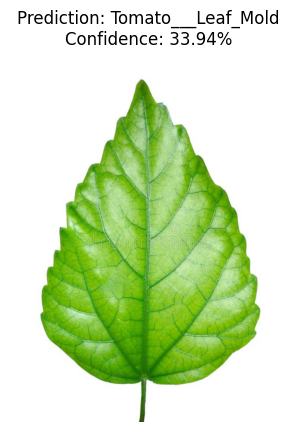

✅ Predicted Disease: Tomato___Leaf_Mold
📊 Confidence: 33.93561


In [32]:
# ==========================================
# CELL 17 : TEST ON SINGLE IMAGE (FINAL)
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Your image path
img_path = r"C:\Users\digvi\Downloads\2656e02fdbc5a5e008551dc53cf6c911.jpg"

# Check if file exists
if not os.path.exists(img_path):
    print("❌ Image not found! Check path:", img_path)

else:
    img = cv2.imread(img_path)

    if img is None:
        print("❌ Failed to read image. File may be corrupted.")
    else:
        # Convert BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize to model input
        img_resized = cv2.resize(img, (224, 224))

        # IMPORTANT: No /255 here (model already has TrueDivide layer)
        img_array = np.expand_dims(img_resized, axis=0)

        # Prediction
        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Show result
        plt.imshow(img)
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
        plt.axis("off")
        plt.show()

        print("✅ Predicted Disease:", predicted_class)
        print("📊 Confidence:", confidence)

In [33]:
# ==========================================
# CELL 18 : SHOW ALL CLASS PROBABILITIES
# ==========================================

for i, prob in enumerate(prediction[0]):
    print(f"{class_names[i]} : {prob*100:.2f}%")

Apple___Apple_scab : 5.35%
Apple___Black_rot : 2.89%
Apple___Cedar_apple_rust : 1.41%
Apple___healthy : 0.85%
Background_without_leaves : 0.03%
Blueberry___healthy : 0.05%
Cherry___Powdery_mildew : 0.87%
Cherry___healthy : 2.44%
Corn___Cercospora_leaf_spot Gray_leaf_spot : 0.01%
Corn___Common_rust : 0.01%
Corn___Northern_Leaf_Blight : 0.01%
Corn___healthy : 0.03%
Grape___Black_rot : 0.37%
Grape___Esca_(Black_Measles) : 1.65%
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 0.12%
Grape___healthy : 0.34%
Orange___Haunglongbing_(Citrus_greening) : 14.26%
Peach___Bacterial_spot : 0.14%
Peach___healthy : 1.98%
Pepper,_bell___Bacterial_spot : 3.05%
Pepper,_bell___healthy : 1.48%
Potato___Early_blight : 3.51%
Potato___Late_blight : 0.11%
Potato___healthy : 0.06%
Raspberry___healthy : 1.19%
Soybean___healthy : 0.05%
Squash___Powdery_mildew : 0.02%
Strawberry___Leaf_scorch : 0.22%
Strawberry___healthy : 4.90%
Tomato___Bacterial_spot : 0.45%
Tomato___Early_blight : 9.80%
Tomato___Late_blight : 4.52%